In [22]:
import pandas as pd
import sklearn
from sklearn.feature_selection import RFE

In [23]:
train = pd.read_csv("train.csv");
test = pd.read_csv("test.csv")

train.dropna(inplace=True);

train = train.sample(frac=1).reset_index(drop=True)

In [24]:
display(train)
display(test)

,id,date,country,store,product,num_sold
0,14859,2010-06-15,Canada,Stickers for Less,Kerneler Dark Mode,735.0
1,139837,2014-04-03,Norway,Stickers for Less,Kaggle Tiers,2311.0
2,185093,2015-08-19,Kenya,Stickers for Less,Kerneler,18.0
3,108340,2013-04-18,Norway,Premium Sticker Mart,Holographic Goose,424.0
4,101568,2013-02-02,Kenya,Discount Stickers,Kerneler,6.0
...,...,...,...,...,...,...
221254,91288,2012-10-11,Finland,Premium Sticker Mart,Kerneler,829.0
221255,200777,2016-02-09,Singapore,Discount Stickers,Kaggle Tiers,729.0
221256,173067,2015-04-07,Singapore,Premium Sticker Mart,Kaggle Tiers,1534.0
221257,153504,2014-09-02,Kenya,Stickers for Less,Kerneler Dark Mode,16.0


,id,date,country,store,product
0,230130,2017-01-01,Canada,Discount Stickers,Holographic Goose
1,230131,2017-01-01,Canada,Discount Stickers,Kaggle
2,230132,2017-01-01,Canada,Discount Stickers,Kaggle Tiers
3,230133,2017-01-01,Canada,Discount Stickers,Kerneler
4,230134,2017-01-01,Canada,Discount Stickers,Kerneler Dark Mode
...,...,...,...,...,...
98545,328675,2019-12-31,Singapore,Premium Sticker Mart,Holographic Goose
98546,328676,2019-12-31,Singapore,Premium Sticker Mart,Kaggle
98547,328677,2019-12-31,Singapore,Premium Sticker Mart,Kaggle Tiers
98548,328678,2019-12-31,Singapore,Premium Sticker Mart,Kerneler


In [25]:
countryes = train["country"].unique();

mp_cty_val = {};

for contry in countryes:
    mp_cty_val[contry] = [train[train["country"] == contry]["num_sold"].min(), train[train["country"] == contry]["num_sold"].max(), train[train["country"] == contry]["num_sold"].mean(), train[train["country"] == contry]["num_sold"].median()]
    

In [26]:
import numpy as np
from tqdm.auto import tqdm

tqdm.pandas()

train["min_num_sold"] = np.zeros(len(train));
train["max_num_sold"] = np.zeros(len(train));
train["mean_num_sold"] = np.zeros(len(train));
train["median_num_sold"] = np.zeros(len(train));


def apply_stuff(row):
    row_cty = row["country"]
    vals = mp_cty_val[row_cty]

    row["min_num_sold"] = vals[0];
    row["max_num_sold"] = vals[1];
    row["mean_num_sold"] = vals[2];
    row["median_num_sold"] = vals[3];

    return row;

train["min_num_sold"] = train["country"].progress_apply(lambda x: mp_cty_val[x][0])
train["max_num_sold"] = train["country"].progress_apply(lambda x: mp_cty_val[x][1])
train["mean_num_sold"] = train["country"].progress_apply(lambda x: mp_cty_val[x][2])
train["median_num_sold"] = train["country"].progress_apply(lambda x: mp_cty_val[x][3])

test["min_num_sold"] = test["country"].progress_apply(lambda x: mp_cty_val[x][0])
test["max_num_sold"] = test["country"].progress_apply(lambda x: mp_cty_val[x][1])
test["mean_num_sold"] = test["country"].progress_apply(lambda x: mp_cty_val[x][2])
test["median_num_sold"] = test["country"].progress_apply(lambda x: mp_cty_val[x][3])


# test = test.progress_apply(apply_stuff, axis=1)

# for i, row in tqdm.tqdm(train.iterrows()):

#     train.iloc[i] = row

100%|██████████| 98550/98550 [00:00<00:00, 797439.27it/s]


In [27]:
train   

,id,date,country,store,product,num_sold,min_num_sold,max_num_sold,mean_num_sold,median_num_sold
0,14859,2010-06-15,Canada,Stickers for Less,Kerneler Dark Mode,735.0,200.0,2749.0,840.045003,731.0
1,139837,2014-04-03,Norway,Stickers for Less,Kaggle Tiers,2311.0,105.0,5939.0,1422.560422,1261.0
2,185093,2015-08-19,Kenya,Stickers for Less,Kerneler,18.0,5.0,73.0,20.431100,18.0
3,108340,2013-04-18,Norway,Premium Sticker Mart,Holographic Goose,424.0,105.0,5939.0,1422.560422,1261.0
4,101568,2013-02-02,Kenya,Discount Stickers,Kerneler,6.0,5.0,73.0,20.431100,18.0
...,...,...,...,...,...,...,...,...,...,...
221254,91288,2012-10-11,Finland,Premium Sticker Mart,Kerneler,829.0,65.0,3173.0,748.243306,665.0
221255,200777,2016-02-09,Singapore,Discount Stickers,Kaggle Tiers,729.0,69.0,2907.0,863.052379,772.0
221256,173067,2015-04-07,Singapore,Premium Sticker Mart,Kaggle Tiers,1534.0,69.0,2907.0,863.052379,772.0
221257,153504,2014-09-02,Kenya,Stickers for Less,Kerneler Dark Mode,16.0,5.0,73.0,20.431100,18.0


In [28]:
test

,id,date,country,store,product,min_num_sold,max_num_sold,mean_num_sold,median_num_sold
0,230130,2017-01-01,Canada,Discount Stickers,Holographic Goose,200.0,2749.0,840.045003,731.0
1,230131,2017-01-01,Canada,Discount Stickers,Kaggle,200.0,2749.0,840.045003,731.0
2,230132,2017-01-01,Canada,Discount Stickers,Kaggle Tiers,200.0,2749.0,840.045003,731.0
3,230133,2017-01-01,Canada,Discount Stickers,Kerneler,200.0,2749.0,840.045003,731.0
4,230134,2017-01-01,Canada,Discount Stickers,Kerneler Dark Mode,200.0,2749.0,840.045003,731.0
...,...,...,...,...,...,...,...,...,...
98545,328675,2019-12-31,Singapore,Premium Sticker Mart,Holographic Goose,69.0,2907.0,863.052379,772.0
98546,328676,2019-12-31,Singapore,Premium Sticker Mart,Kaggle,69.0,2907.0,863.052379,772.0
98547,328677,2019-12-31,Singapore,Premium Sticker Mart,Kaggle Tiers,69.0,2907.0,863.052379,772.0
98548,328678,2019-12-31,Singapore,Premium Sticker Mart,Kerneler,69.0,2907.0,863.052379,772.0


In [29]:
from sklearn.preprocessing import LabelEncoder

enc_cols = ["country", "store", "product"];

for enc_col in enc_cols:
    enc_name = LabelEncoder().fit(train[enc_col]);
    train[enc_col] = enc_name.transform(train[enc_col])
    test[enc_col] = enc_name.transform(test[enc_col])


In [30]:
train

,id,date,country,store,product,num_sold,min_num_sold,max_num_sold,mean_num_sold,median_num_sold
0,14859,2010-06-15,0,2,4,735.0,200.0,2749.0,840.045003,731.0
1,139837,2014-04-03,4,2,2,2311.0,105.0,5939.0,1422.560422,1261.0
2,185093,2015-08-19,3,2,3,18.0,5.0,73.0,20.431100,18.0
3,108340,2013-04-18,4,1,0,424.0,105.0,5939.0,1422.560422,1261.0
4,101568,2013-02-02,3,0,3,6.0,5.0,73.0,20.431100,18.0
...,...,...,...,...,...,...,...,...,...,...
221254,91288,2012-10-11,1,1,3,829.0,65.0,3173.0,748.243306,665.0
221255,200777,2016-02-09,5,0,2,729.0,69.0,2907.0,863.052379,772.0
221256,173067,2015-04-07,5,1,2,1534.0,69.0,2907.0,863.052379,772.0
221257,153504,2014-09-02,3,2,4,16.0,5.0,73.0,20.431100,18.0


In [31]:
def split_date(df):
    df["year"] = df["date"].apply(lambda x: int(x.split('-')[0]));
    # df["month"] = df["date"].apply(lambda x: int(x.split('-')[1]));
    # df["days"] = df["date"].apply(lambda x: int(x.split('-')[2]));

    return df;

train = split_date(train);
test = split_date(test);

train.drop(columns="date", inplace=True);
test.drop(columns="date", inplace=True);


In [32]:
test_ids = test["id"];
train_labels = train["num_sold"]

train.drop(columns=["id", "num_sold"], inplace=True);
test.drop(columns=["id"], inplace=True);

In [33]:
from sklearn.preprocessing import *

scl = MinMaxScaler().fit(train);

train = pd.DataFrame(scl.transform(train), train.index, train.columns)
test = pd.DataFrame(scl.transform(test), test.index, test.columns)


In [34]:
display(train)
display(test)

,country,store,product,min_num_sold,max_num_sold,mean_num_sold,median_num_sold,year
0,0.0,1.0,1.00,1.000000,0.456188,0.584549,0.573612,0.000000
1,0.8,1.0,0.50,0.512821,1.000000,1.000000,1.000000,0.666667
2,0.6,1.0,0.75,0.000000,0.000000,0.000000,0.000000,0.833333
3,0.8,0.5,0.00,0.512821,1.000000,1.000000,1.000000,0.500000
4,0.6,0.0,0.75,0.000000,0.000000,0.000000,0.000000,0.500000
...,...,...,...,...,...,...,...,...
221254,0.2,0.5,0.75,0.307692,0.528469,0.519076,0.520515,0.333333
221255,1.0,0.0,0.50,0.328205,0.483123,0.600958,0.606597,1.000000
221256,1.0,0.5,0.50,0.328205,0.483123,0.600958,0.606597,0.833333
221257,0.6,1.0,1.00,0.000000,0.000000,0.000000,0.000000,0.666667


,country,store,product,min_num_sold,max_num_sold,mean_num_sold,median_num_sold,year
0,0.0,0.0,0.00,1.000000,0.456188,0.584549,0.573612,1.166667
1,0.0,0.0,0.25,1.000000,0.456188,0.584549,0.573612,1.166667
2,0.0,0.0,0.50,1.000000,0.456188,0.584549,0.573612,1.166667
3,0.0,0.0,0.75,1.000000,0.456188,0.584549,0.573612,1.166667
4,0.0,0.0,1.00,1.000000,0.456188,0.584549,0.573612,1.166667
...,...,...,...,...,...,...,...,...
98545,1.0,0.5,0.00,0.328205,0.483123,0.600958,0.606597,1.500000
98546,1.0,0.5,0.25,0.328205,0.483123,0.600958,0.606597,1.500000
98547,1.0,0.5,0.50,0.328205,0.483123,0.600958,0.606597,1.500000
98548,1.0,0.5,0.75,0.328205,0.483123,0.600958,0.606597,1.500000


In [35]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import *


selector = RFE(ExtraTreesRegressor(n_estimators=1000, n_jobs=-1, verbose=1), n_features_to_select=6).fit(train, train_labels)

train = selector.transform(train)
test = selector.transform(test)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done 418 tasks      | elapsed:    8.8s
[Parallel(n_jobs=-1)]: Done 768 tasks      | elapsed:   16.8s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:   21.5s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    3.2s
[Parallel(n_jobs=-1)]: Done 418 tasks      | elapsed:    7.9s
[Parallel(n_jobs=-1)]: Done 768 tasks      | elapsed:   14.5s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:   19.1s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elaps

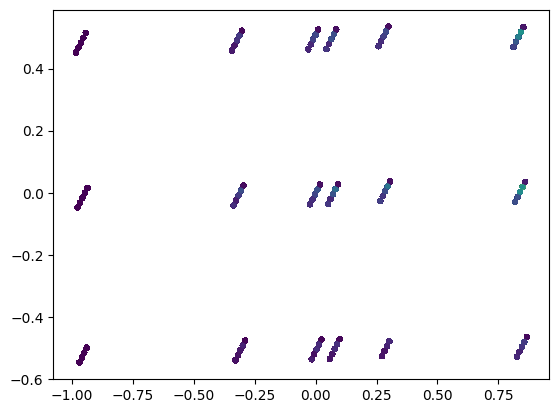

In [36]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

points = PCA(2).fit_transform(train, train_labels);
            
plt.scatter(points[:, 0], points[:, 1], c=train_labels, marker='.')

In [39]:
from sklearn.neural_network import MLPRegressor

model = GradientBoostingRegressor(n_estimators=1500, verbose=1, learning_rate=0.05).fit(train, train_labels)

      Iter       Train Loss   Remaining Time 
         1      449217.7856            3.36m
         2      422335.0604            3.03m
         3      399428.0377            2.87m
         4      376618.1805            2.73m
         5      355586.1870            2.88m
         6      336423.1843            2.84m
         7      319311.6357            2.77m
         8      302857.8186            2.74m
         9      287632.1124            2.71m
        10      273763.3109            2.68m
        20      176317.0249            2.56m
        30      121555.5340            2.47m
        40       89713.3201            2.41m
        50       71085.1407            2.38m
        60       59231.6854            2.35m
        70       51511.8209            2.32m
        80       46014.1286            2.30m
        90       42201.3727            2.28m
       100       39407.2261            2.26m
       200       31426.9888            2.09m
       300       29619.0793            1.92m
       40

In [40]:
pred = model.predict(test)

In [41]:
ans = pd.DataFrame();

ans["id"] = test_ids;
ans["num_sold"] = pred;

ans.to_csv("ans.csv", index=False)